<font color='IndianRed'>
<font size=9> 

**Curso Inferencia Estadística**

<font color = 'DodgerBlue'>
<font size = 5>
    
**Resumen de regresión lineal**

<font color = 'Black'>
<font size = 3>

En el repositorio del scripts del curso están el script [linear_reg_function.py](https://github.com/scidatmath2020/Inferencia_Estadistica_2024/blob/main/scripts/linear_reg_function.py) que es donde se han programado todos los pasos para la **regresión**.

<font color = 'Black'>
<font size = 3>

Se sugiere utilizar el siguiente preámbulo de trabajo:

```python
################################################################
########################    EN PYTHON    #######################
################################################################

import os
ruta_funcion = # ruta donde descargaste la función
os.chdir(ruta_funcion)
from linear_reg_function import *

####################################################################

ruta_tabla = # ruta donde está tu tabla
os.chdir(ruta_tabla)

data = pd.read_csv(ruta_tabla)
Y = #nombre de la columna objetivo
predictores = #lista de nombres de las columnas predictoras

################################################################
```

<font color = 'Black'>
<font size = 3>

---

Función de regresión lineal:

```python
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import *
import itertools
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, norm, anderson, jarque_bera,t, stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Para que muestre todas las columnas de los dataframes
pd.set_option('display.max_columns', None)

#%%

def linear_regression(data, target, predictors, best_ml = True):
    '''
    Nos devuelve un diagnóstico completo de una regresión lineal.
    
    data: nombre de la tabla
    target: nombre de la variable objetivo. Es un string
    predictors: lista de variables predictoras
    best_ml: Si True, indica que se busca el mejor modelo con las columnas predictors.
             Si False, indica que se busca el modelo lineal con exactamente las variables predictors.
             
    Devuelve una tupla de 21 objetos:
    modelo: modelo entrenado
    params: los coeficientes estimados b_i
    ci_params: los intervalos de confianza para los b_i 
    r2: R^2 del modelo (porcentaje de la varianza de Y explicada a través del modelo) 
    r2_adj: R^2 ajustado del modelo
    AIC: información de Akaike
    residuos: residuos del modelo
    residuos_qq: gráfico qq de los residuos
    residuos_hist: gráfico histograma de los residuos
    gaussianidad_residuos: resultados de la prueba de gaussianidad
    homocedasticidad_grafica: gráfico de las estimaciones del modelo vs residuos
    bp_p_value: p-valor del test de Breuch-Pagan para homocedasticidad de los residuos
    resultado_bptest: resultado del test de Breuch-Pagan para homocedasticidad de los residuos
    dw_stat: valor del estadístico de Durwin-Watson para identificar autocorrelación de los residuos
    resultado_dw: resultado del test de Durwin-Watson para identificar autocorrelación de los residuos
    p_value_tukey: p-valor del test de Tukey para aditividad
    resultado_pval_tukey: resultado del test de Tukey para aditividad
    residuos_parciales_grafica: gráfico de los residuos parciales para analizar linealidad
    indices_alto_leverage: índices de la tabla que presentan un alto apalancamiento
    indices_outliers_significativos: índices de la tabla que presentan un valor anómalo en la columna objetivo
    indices_alta_influencia: leverage alto y outlier. Afectan fuertemente a la regresión    
    predictores: columnas con las cuales se realizó la regresión final
    '''
    
    def gaussian_test(lista):
        shapiro_test = shapiro(lista)
        ks_test = kstest(lista,"norm",args=(np.mean(lista),np.std(lista,ddof=1)))
        jb_test = jarque_bera(lista)
        p_valores = [shapiro_test.pvalue, ks_test.pvalue,jb_test.pvalue] 
        rech = ["Rechazar H0","No rechazar H0"]
        significados = ["Hay buena probabilidad de que NO es gaussiana",
                        "Hay buena probabilidad de que SÍ es gaussiana"]
            
        resultados = pd.DataFrame({"Prueba":["SW","KS","JB"],
         "p_valor":p_valores,
         "Resultado":[rech[0] if x<0.05 else rech[1] for x in p_valores],
         "Interpretación":[significados[0] if x<0.05 else significados[1] for x in p_valores]
        })
        
        anderson_test = anderson(lista,dist="norm")
        est_A = anderson_test.statistic
        resultados_anderson = pd.DataFrame({"Estadístico A":5*[est_A],#,"","","","",""],
                                            "Significancia":anderson_test.significance_level,
                                            "Valor_crítico":anderson_test.critical_values,
                                            "Resultado":[rech[0] if est_A > anderson_test.critical_values[i] else rech[1] for i in range(5)],
                                            "Interpretación":[significados[0] if est_A > anderson_test.critical_values[i] else significados[1] for i in range(5)]})
        return  resultados, resultados_anderson
    
    def stepwise_selection(data, target, predictors):
        """
        data: DataFrame con los datos.
        target: Nombre de la columna dependiente (Y).
        predictors: Lista de nombres de las columnas independientes (X).
        """
        best_aic = float('inf')
        best_model = None
        best_predictors = []

        # Generar todos los subconjuntos posibles de las variables independientes
        for k in range(1, len(predictors) + 1):
            for subset in itertools.combinations(predictors, k):
                X = sm.add_constant(data[list(subset)])  # Agregar el término constante
                Y = data[target]
                model = sm.OLS(Y, X).fit()
                aic = model.aic
                r2 = model.rsquared
                r2_adj = model.rsquared_adj
                
                if aic < best_aic:  # Comparar el AIC
                    best_aic = aic
                    best_model = model
                    best_predictors = list(subset)
        
        return best_model, best_predictors
    
    if best_ml == True:
        modelo, predictores = stepwise_selection(data,target,predictors)
    else:
        X = sm.add_constant(data[predictors]) 
        y = data[target]
        modelo = sm.OLS(y,X).fit()
        predictores = predictors
    
    X = sm.add_constant(data[predictores])
    y = data[target]
    
    r2 = modelo.rsquared
    r2_adj = modelo.rsquared_adj
    AIC = modelo.aic
    
    n = len(data)  # Número de observaciones
    k = len(predictores)  # Número de predictores (excluye intercepto)
    
    residuos = modelo.resid
    
    gaussianidad_residuos = gaussian_test(residuos)
    tabla_residuos = pd.DataFrame({"value": residuos})
    
    residuos_qq = (ggplot(tabla_residuos, aes(sample="value")) +
        geom_qq() +  # Puntos del gráfico QQ
        geom_qq_line(color="red") +  # Línea de referencia en rojo
        theme(figure_size=(8, 6))
    )
    
    bins_sturges = int(np.ceil(np.log2(n) + 1)) 
    residuos_hist = (ggplot(data=tabla_residuos) +
                         geom_histogram(mapping=aes(x="value"),
                                        fill = "blue",
                                        color = "white",
                                        bins=bins_sturges)
                     )
    
    y_gorro = modelo.fittedvalues
    var_errores = pd.DataFrame({"y_gorro":y_gorro, "residuos":residuos})
    
    homocedasticidad_grafica = (ggplot(data=var_errores) + 
     geom_point(mapping=aes(x="y_gorro",y="residuos"),color="blue") +
     geom_hline(yintercept=0)
    )
    
    bp_test = het_breuschpagan(residuos, X)
    bp_stat = bp_test[0]   # Estadístico de la prueba
    bp_p_value = bp_test[1]  # p-valor asociado
    
    if bp_p_value > 0.05:
        resultado_bptest = "No se rechaza la hipótesis nula: los errores son homocedásticos."
    else:
        resultado_bptest = "Se rechaza la hipótesis nula: los errores no son homocedásticos."

    dw_stat = durbin_watson(residuos)
    if dw_stat < 1.5:
        resultado_dw = "Posible autocorrelación positiva en los residuos."
    elif dw_stat > 2.5:
        resultado_dw = "Posible autocorrelación negativa en los residuos."
    else:
        resultado_dw = "No hay evidencia significativa de autocorrelación en los residuos."
        
    X_copia = data.copy()
    X_copia["fitted"] = modelo.fittedvalues
    X_copia["fitted_squared"] = X_copia["fitted"]**2
    
    
    formula = f"{target} ~ " + " + ".join(predictores) + " + fitted_squared"
    modelo_tukey = smf.ols(formula, data=X_copia).fit()
    p_value_tukey = modelo_tukey.pvalues["fitted_squared"]
    
    if p_value_tukey < 0.05:
        resultado_pval_tukey = f"p-valor de Tukey: {p_value_tukey:.4f} - Rechazamos H0: el modelo NO es aditivo."
    else:
        resultado_pval_tukey = f"p-valor de Tukey: {p_value_tukey:.4f} - No Rechazamos H0: el modelo es aditivo."

    res_partial = [modelo.resid + modelo.params[x]*X.iloc[:,x] for x in range(1,k+1)]

    partial = pd.concat([pd.DataFrame({"Component+Residual(Y)":res_partial[x],
                   "type":predictores[x],
                   "X":X.iloc[:,x+1]}) for x in range(k)])

    residuos_parciales_grafica = (
    ggplot(data=partial) + 
        geom_point(mapping=aes(x="X",y="Component+Residual(Y)"),size=1,shape="o",fill="white") +
        geom_smooth(mapping=aes(x="X",y="Component+Residual(Y)"),method="lm",color="red",se=False) +
        facet_wrap("~type",scales="free_y",ncol=2) +
        theme(
            figure_size=(10, 6),
            plot_background=element_rect(fill="white"),
            panel_background=element_rect(fill="white"),
            panel_grid=element_line(color="gray", size=0.5),  # Cuadrícula de fondo
            panel_border=element_rect(color="black", size=0.5),  # Contorno rectangular de cada subgráfica
            strip_background=element_rect(fill="lightgray", color="black", size=0.5),  # Fondo y contorno del título de la faceta
            strip_text=element_text(color="black", size=12)  # Color y tamaño del texto del título de la faceta
        )
    )

    # Valores de apalancamiento
    influence = modelo.get_influence()
    hat_values = influence.hat_matrix_diag

    # Umbral para valores altos de apalancamiento
    high_leverage_threshold = 2 * (k + 1) / n
    high_leverage_points = np.where(hat_values > high_leverage_threshold)[0]
    indices_alto_leverage = high_leverage_points
    
    # Residuos estudiantizados
    studentized_residuals = influence.resid_studentized_external
    p_values_outliers = 2 * (1 - t.cdf(np.abs(studentized_residuals), df=n - k - 1))

    # Filtrar outliers significativos (ejemplo con p < 0.05)
    outliers = np.where(p_values_outliers < 0.05)[0]
    indices_outliers_significativos = outliers
    
    # Distancia de Cook
    cooks_d = influence.cooks_distance[0]

    # Umbral para alta influencia
    cooks_threshold = 4 / (n - k - 2)
    high_influence_points = np.where(cooks_d > cooks_threshold)[0]
    indices_alta_influencia = high_influence_points
    
    params = modelo.params
    ci_params = modelo.conf_int()
    
    return modelo, params, ci_params, r2, r2_adj, AIC, residuos, residuos_qq, residuos_hist, gaussianidad_residuos, homocedasticidad_grafica, bp_p_value, resultado_bptest, dw_stat, resultado_dw, p_value_tukey, resultado_pval_tukey, residuos_parciales_grafica, indices_alto_leverage, indices_outliers_significativos, indices_alta_influencia, predictores
```

<font color = 'Black'>
<font size = 3>

---

Podemos usar nuestras propias funciones e importarlas en Python. Vamos a importar la función que se muestra en la celda anterior. **La celda anterior es Markdown**. 

El script se encuentra descargado en la carpeta de scripts, así como lo hacemos de la siguiente manera:

In [1]:
import os
ruta_funcion = "/home/zick13/Documentos/Developer/Courses/Inferencia_Estadistica/Scripts"
os.chdir(ruta_funcion) # se dirige a esa ruta
from linear_reg_function import * # de ese archivo, trae todo

In [2]:
# Nos movemos a la carpeta donde se encuentran las tablas
ruta_tabla = "/home/zick13/Documentos/Developer/Courses/Inferencia_Estadistica/Clases/10_Regresiones_lineales/Data"
os.chdir(ruta_tabla)

# Leer la tabla
data = pd.read_csv("datos_regresion.csv")

# Muestra la tabla
print(data.head())

# Muestra el nombre de las columnas
print(data.columns)

         X1        X2        X3        X4        X5       hola          Y
0  3.745401  0.314292  6.420316  0.516817  1.031239   2.104191  25.355024
1  9.507143  6.364104  0.841400  5.313546  9.025529   2.031724  21.244012
2  7.319939  3.143560  1.616287  5.406351  5.052524 -10.281137  23.659134
3  5.986585  5.085707  8.985542  6.374299  8.264575 -10.627790  21.688336
4  1.560186  9.075665  6.064291  7.260913  3.200496  -7.517386  -0.101104
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'hola', 'Y'], dtype='object')


In [3]:
# Nombre de la columna objetivo o la columna que quieres predecir
Y = "Y"

# Lista de nombres de las columnas predictoras
predictores = ["X1", "X2", "X3", "X4", "X5", "hola"]

<font color = 'DodgerBlue'>
<font size = 5>
    
**Planteamiento del modelo**

<font color = 'DodgerBlue'>
<font size = 5>
    
**Paso 1. Establecer el modelo**

<font color = 'Black'>
<font size = 3>

Decidimos si trabajar con algunas columnas de la tabla o con el modelo con menor **Índice de Akaike**.

```python
################################################################
########################    EN PYTHON    #######################
################################################################

mi_regresion = linear_regression(data,Y,predictores,best_ml = True)

################################################################
```

donde

- ``best_ml=True`` indica que se buscará el modelo con menor **índice de Akaike** de entre todos los modelos posibles que se pueden establecer con las columnas ``predictores``; y ``best_ml=False`` indica que se trabajará con exactamente las columnas ``predictores`` y no se buscará el mejor modelo.

In [4]:
mi_regresion = linear_regression(data, Y, predictores, best_ml = True) # best_ml=True encuentra el mejor modelo con menor akaike

/home/zick13/Documentos/Developer/Courses/Inferencia_Estadistica/Scripts/linear_reg_function.py:186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [5]:
mi_regresion

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7efeb193a470>,
 const    5.338527
 X1       3.838879
 X3       1.400344
 X4      -2.945864
 X5      -0.812063
 hola    -0.656878
 dtype: float64,
               0         1
 const  3.529709  7.147345
 X1     3.688806  3.988952
 X3     1.254442  1.546247
 X4    -3.232276 -2.659452
 X5    -0.945776 -0.678350
 hola  -0.704412 -0.609343,
 np.float64(0.9721962360403482),
 np.float64(0.9707173124254731),
 np.float64(434.2918456922467),
 0     0.389802
 1     2.547340
 2     1.232778
 3    -0.706804
 4    -0.870428
         ...   
 95   -1.184862
 96   -2.492117
 97   -0.056006
 98   -0.207242
 99   -2.186003
 Length: 100, dtype: float64,
 (  Prueba   p_valor       Resultado  \
  0     SW  0.349122  No rechazar H0   
  1     KS  0.838809  No rechazar H0   
  2     JB  0.653503  No rechazar H0   
  
                                    Interpretación  
  0  Hay buena probabilidad de que SÍ es gaussiana  
  1  Hay buena probabil

In [6]:
# Consultamos la documentación o ayuda
?linear_regression

Signature: linear_regression(data, target, predictors, best_ml=True)
Docstring:
Nos devuelve un diagnóstico completo de una regresión lineal.

data: nombre de la tabla
target: nombre de la variable objetivo. Es un string
predictors: lista de variables predictoras
best_ml: Si True, indica que se busca el mejor modelo con las columnas predictors.
         Si False, indica que se busca el modelo lineal con exactamente las variables predictors.
         
Devuelve una tupla de 21 objetos:
modelo: modelo entrenado
params: los coeficientes estimados b_i
ci_params: los intervalos de confianza para los b_i 
r2: R^2 del modelo (porcentaje de la varianza de Y explicada a través del modelo) 
r2_adj: R^2 ajustado del modelo
AIC: información de Akaike
residuos: residuos del modelo
residuos_qq: gráfico qq de los residuos
residuos_hist: gráfico histograma de los residuos
gaussianidad_residuos: resultados de la prueba de gaussianidad
homocedasticidad_grafica: gráfico de las estimaciones del modelo vs r

<font color = 'DodgerBlue'>
<font size = 5>

---
    
**Construcción del modelo**

<font color = 'Black'>
<font size = 3>

```python
################################################################
########################    EN PYTHON    #######################
################################################################

claves = [
    "modelo", "parametros", "intervalos_de_confianza", "r2", "r2_adj", "AIC",
    "residuos", "residuos_qq", "residuos_histograma", "gaussianidad_residuos",
    "homocedasticidad_grafica", "bp_p_value", "resultado_bptest", "dw_stat",
    "resultado_dw", "p_value_tukey", "resultado_pval_tukey", 
    "residuos_parciales_grafica", "indices_alto_leverage", 
    "indices_outliers_significativos", "indices_alta_influencia", "predictores"
]

resultado = dict(zip(claves, mi_regresion))

################################################################
```

In [7]:
# Le pone el nombre a esos 21 objetos de la tupla que nos devuelve la función anterior
claves = [
    "modelo", "parametros", "intervalos_de_confianza", "r2", "r2_adj", "AIC",
    "residuos", "residuos_qq", "residuos_histograma", "gaussianidad_residuos",
    "homocedasticidad_grafica", "bp_p_value", "resultado_bptest", "dw_stat",
    "resultado_dw", "p_value_tukey", "resultado_pval_tukey", 
    "residuos_parciales_grafica", "indices_alto_leverage", 
    "indices_outliers_significativos", "indices_alta_influencia", "predictores"
]

resultado = dict(zip(claves, mi_regresion))

In [8]:
resultado

{'modelo': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7efeb193a470>,
 'parametros': const    5.338527
 X1       3.838879
 X3       1.400344
 X4      -2.945864
 X5      -0.812063
 hola    -0.656878
 dtype: float64,
 'intervalos_de_confianza':               0         1
 const  3.529709  7.147345
 X1     3.688806  3.988952
 X3     1.254442  1.546247
 X4    -3.232276 -2.659452
 X5    -0.945776 -0.678350
 hola  -0.704412 -0.609343,
 'r2': np.float64(0.9721962360403482),
 'r2_adj': np.float64(0.9707173124254731),
 'AIC': np.float64(434.2918456922467),
 'residuos': 0     0.389802
 1     2.547340
 2     1.232778
 3    -0.706804
 4    -0.870428
         ...   
 95   -1.184862
 96   -2.492117
 97   -0.056006
 98   -0.207242
 99   -2.186003
 Length: 100, dtype: float64,
 'residuos_qq': <plotnine.ggplot.ggplot at 0x7efeb19c7520>,
 'residuos_histograma': <plotnine.ggplot.ggplot at 0x7efeb19f30a0>,
 'gaussianidad_residuos': (  Prueba   p_valor       Resultado  \
  0     SW  0

<font color = 'DodgerBlue'>
<font size = 5>

---
    
**Paso 2. Información de los parámetros del modelo.**

<font color = 'Black'>
<font size = 3>

Encontrar los valores estimados $b_0$, $b_1$,...,$b_k$ con sus **intervalos de confianza** y p-valores de **significancia**:

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["parametros"]  # da los coeficientes b_i

################################################################
```

In [9]:
# Muestra el valor de las b_0, b_1, ..., b_k
resultado["parametros"]  # da los coeficientes b_i y te dice quién es el mejor modelo

const    5.338527
X1       3.838879
X3       1.400344
X4      -2.945864
X5      -0.812063
hola    -0.656878
dtype: float64

In [10]:
# Muestra toda la información del modelo. Muestra los coeficientes (beta_0, beta_1, etc.)
resultado["modelo"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     657.4
Date:                Fri, 24 Jan 2025   Prob (F-statistic):           1.81e-71
Time:                        10:58:29   Log-Likelihood:                -211.15
No. Observations:                 100   AIC:                             434.3
Df Residuals:                      94   BIC:                             449.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3385      0.911      5.860      0.000       3.530       7.147
X1             3.8389      0.076     50.790      0.000       3.689       3.989
X3             1.4003      0.073     19.057      0.000       1.254       1.546
X4            -2.9459      0.144    -20.422      0.000      -3.232      -2.659
X5            -0.8121      0.067    -12.058      0.000      -0.946      -0.678
hola          -0.6569      0.024    -27.438      0.000      -0.704      -0.609
==============================================================================
Omnibus:                        0.796   Durbin-Watson:                   1.768
Prob(Omnibus):                  0.672   Jarque-Bera (JB):                0.851
Skew:                          -0.071   Prob(JB):                        0.654
Kurtosis:                       2.571   Cond. No.                         85.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color = 'DodgerBlue'>
<font size = 5>

---
    
**Paso 3. Calificación del modelo.**

<font color = 'Black'>
<font size = 3>

Encontrar los valores $R^2$, $R^2$ **ajustado** y el **Índice de Akaike:**

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["r2"]  # da el valor de R2
resultado["r2_adj"] # da el valor de R2 ajustado
resultado["AIC"] # da el valor del Índice de Akaike

################################################################
```

In [11]:
# Da el valor de R2
resultado["r2"] # muy próximo a 1 es muy buena regresión

np.float64(0.9721962360403482)

In [12]:
# Da el valor de R2 ajustado
resultado["r2_adj"] # muy próximo a 1 es muy buena regresión

np.float64(0.9707173124254731)

In [13]:
# Da el valor del Índice de Akaike
resultado["AIC"]

np.float64(434.2918456922467)

<font color = 'DodgerBlue'>
<font size = 5>

---
    
**Diagnósticos de la regresión**

<font color = 'DodgerBlue'>
<font size = 5>

**Paso 4.  Verificamos la normalidad de los residuos**

<font color = 'Black'>
<font size = 3>

Se aplican las pruebas de **gaussianidad** a los **residuos**

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["residuos"]  # devuelve los residuos
resultado["residuos_qq"] # devuelve el QQ-plot de los residuos
resultado["residuos_histograma"] # devulve el histograma de los residuos
resultado["gaussianidad_residuos"] # devuelve el resultado de las pruebas de gaussianidad a los residuos

################################################################
```

**Reglas de decisión**

$p$-valor|Decisión|Significado
:--|:--|:--
Pequeño|Rechazar $H_0$|Hay buena probabilidad de que **NO es gaussiana**
Grande|Rechazar $H_1$|Hay buena probabilidad de que **SÍ es gaussiana**

In [15]:
# Devuelve los residuos
resultado["residuos"]

0     0.389802
1     2.547340
2     1.232778
3    -0.706804
4    -0.870428
        ...   
95   -1.184862
96   -2.492117
97   -0.056006
98   -0.207242
99   -2.186003
Length: 100, dtype: float64

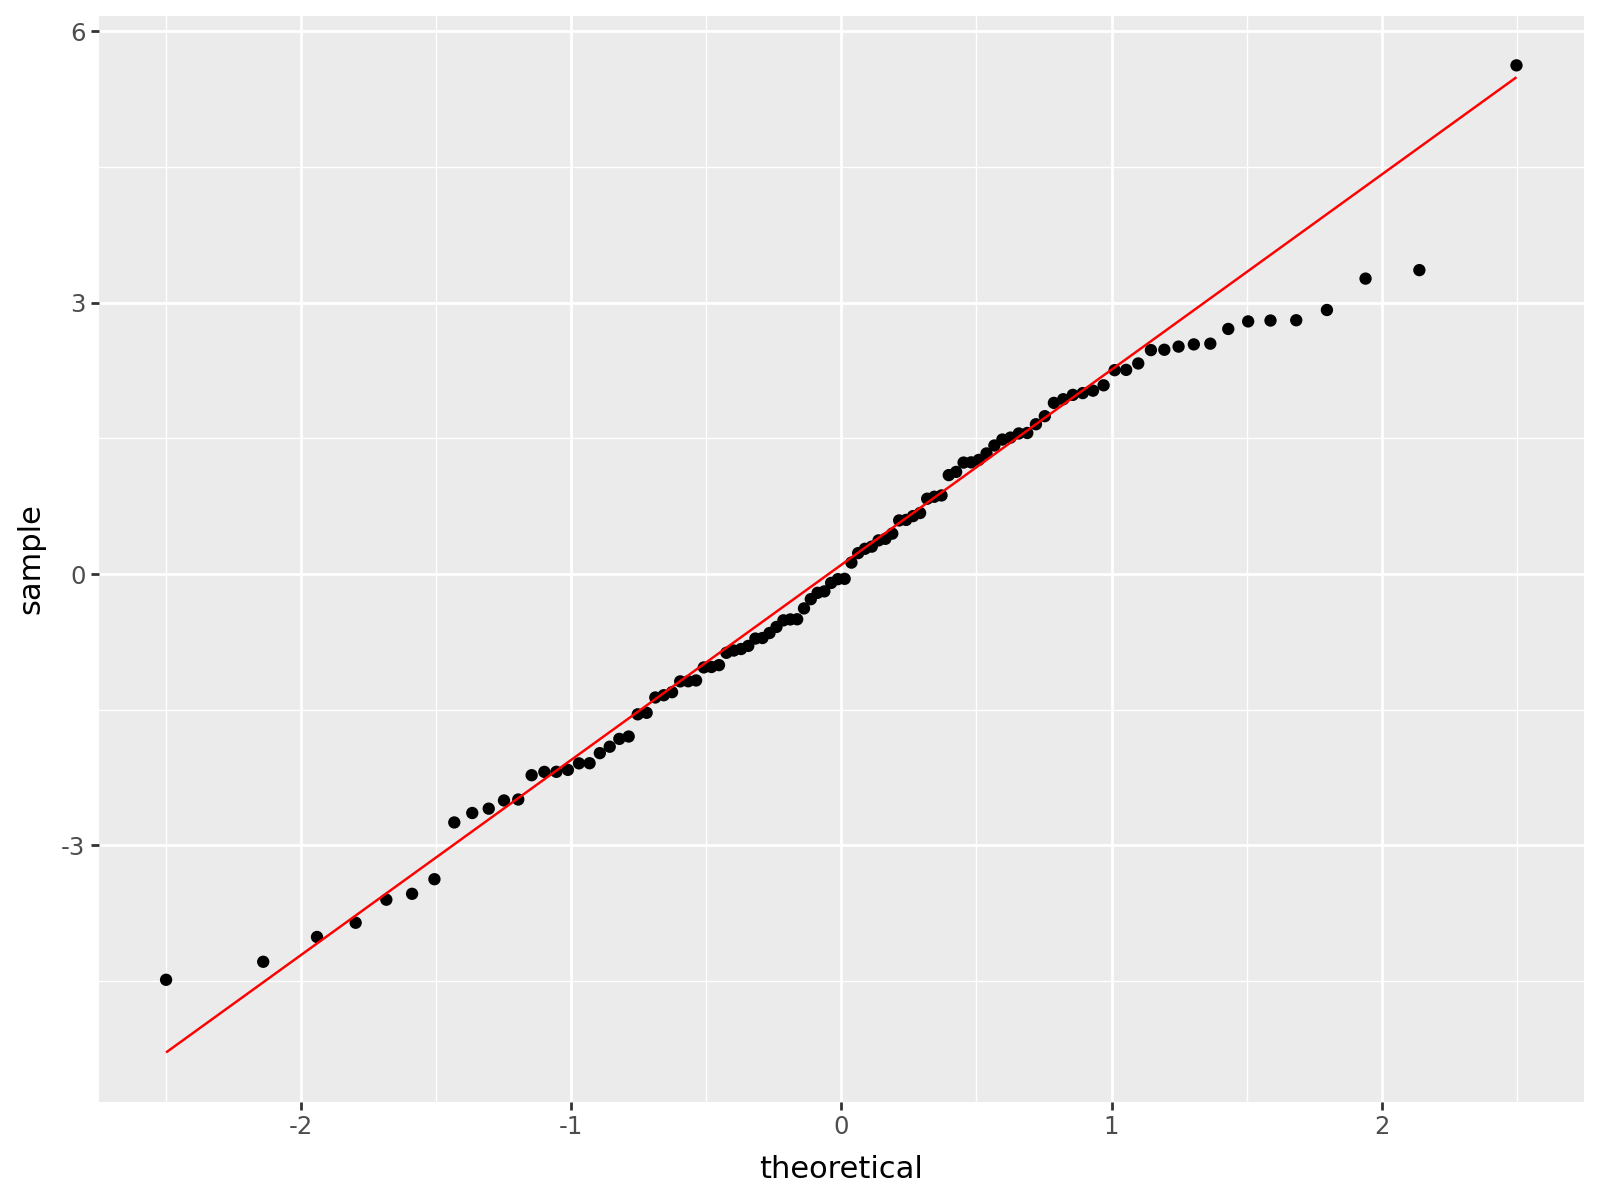

In [16]:
# Devuelve el QQ-plot de los residuos
resultado["residuos_qq"]

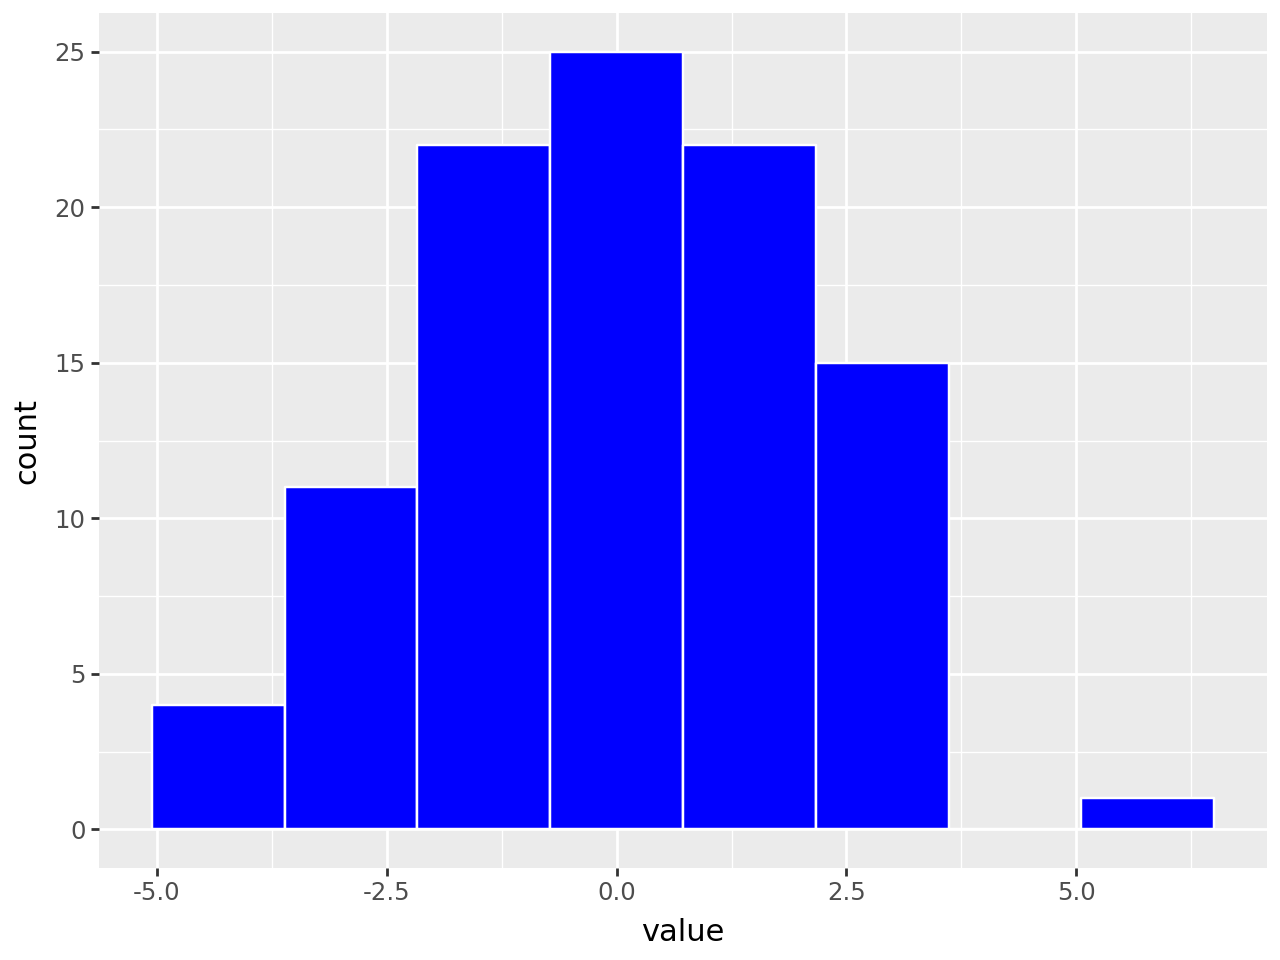

In [17]:
# Devulve el histograma de los residuos
resultado["residuos_histograma"]

In [18]:
# Devuelve el resultado de las pruebas de gaussianidad a los residuos: 3 clásicas y la de Anderson
resultado["gaussianidad_residuos"] 

(  Prueba   p_valor       Resultado  \
 0     SW  0.349122  No rechazar H0   
 1     KS  0.838809  No rechazar H0   
 2     JB  0.653503  No rechazar H0   
 
                                   Interpretación  
 0  Hay buena probabilidad de que SÍ es gaussiana  
 1  Hay buena probabilidad de que SÍ es gaussiana  
 2  Hay buena probabilidad de que SÍ es gaussiana  ,
    Estadístico A  Significancia  Valor_crítico       Resultado  \
 0        0.40531           15.0          0.555  No rechazar H0   
 1        0.40531           10.0          0.632  No rechazar H0   
 2        0.40531            5.0          0.759  No rechazar H0   
 3        0.40531            2.5          0.885  No rechazar H0   
 4        0.40531            1.0          1.053  No rechazar H0   
 
                                   Interpretación  
 0  Hay buena probabilidad de que SÍ es gaussiana  
 1  Hay buena probabilidad de que SÍ es gaussiana  
 2  Hay buena probabilidad de que SÍ es gaussiana  
 3  Hay buena probabi

<font color = 'Black'>
<font size = 3>

**Con toda seguridad decimos que los residuos son gaussianos.**

---

<font color = 'DodgerBlue'>
<font size = 5>

**Paso 5. Homocedasticidad de los residuos: Test de Breuch-Pagan**

<font color = 'Black'>
<font size = 3>

Se aplica la **prueba de Breuch-Pagan** al modelo.

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["homocedasticidad_grafica"] #devuelve el gráfico de la homocedasticidad
resultado["bp_p_value"] # devuelve el p-valor de la prueba de Breuch-Pagan
resultado["resultado_bptest"] # indica si hay o no homocedasticidad

################################################################
```

**Regla de decisión.** Observar un cielo estrellado en el gráfico de **homocedasticidad** y  

$p$-valor|Decisión|Significado
:--|:--|:--
Pequeño|Rechazar $H_0$|Hay buena probabilidad de que los residuos **NO sean homocedásticos**
Grande|Rechazar $H_1$|Hay buena probabilidad de que los residuos **SÍ sean homocedásticos**

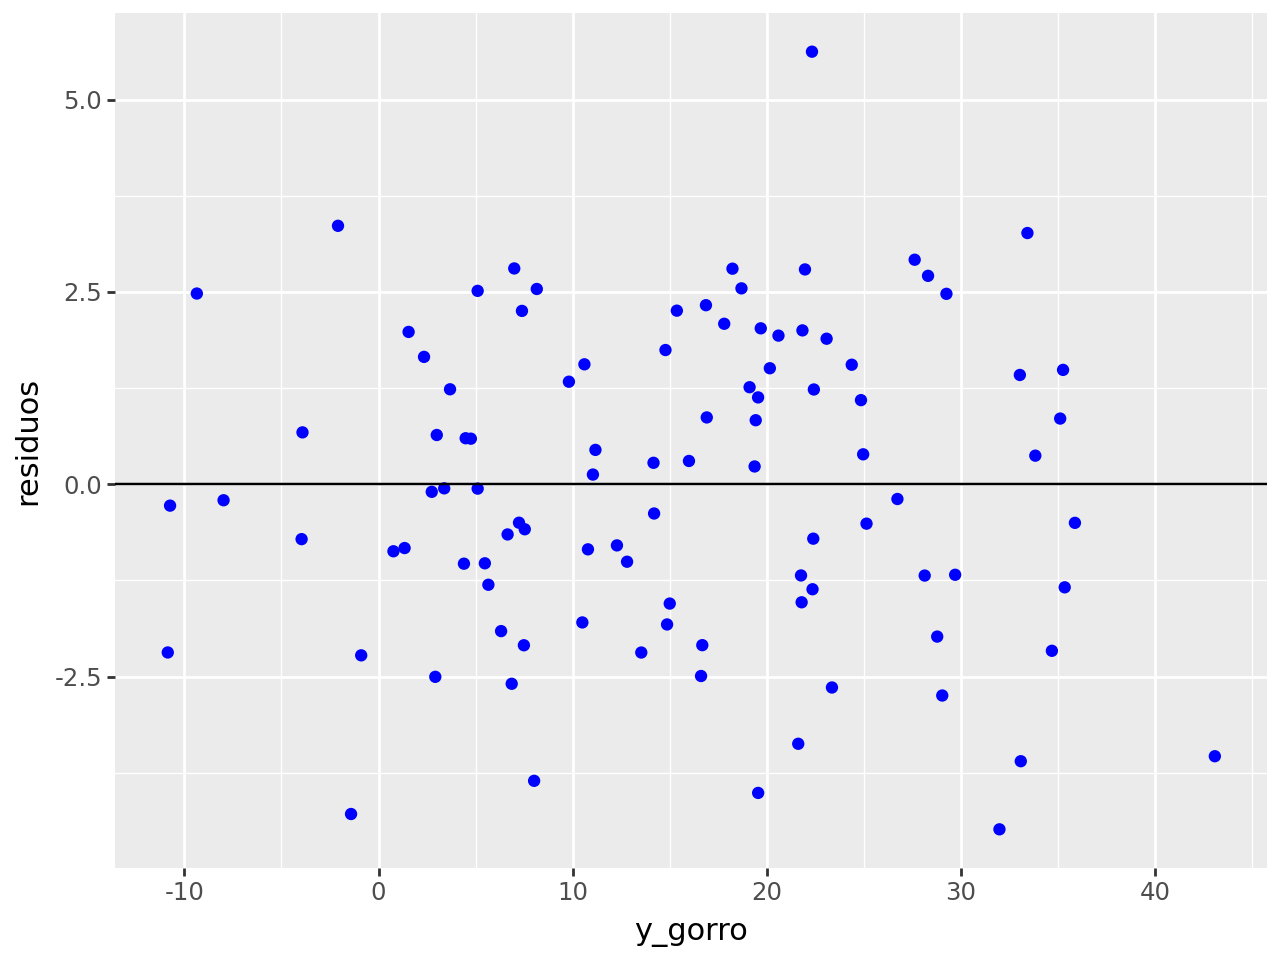

In [21]:
# Devuelve el gráfico de la homocedasticidad, buscamos que se vea como cielo estrellado
resultado["homocedasticidad_grafica"]

In [22]:
# Devuelve el p-valor de la prueba de Breuch-Pagan
resultado["bp_p_value"]

np.float64(0.2764263911764729)

In [23]:
# Indica si hay o no homocedasticidad
resultado["resultado_bptest"]

'No se rechaza la hipótesis nula: los errores son homocedásticos.'

<font color = 'DodgerBlue'>
<font size = 5>

---

**Paso 6. Residuos no correlacionados (independientes): Test de Durbin-Watson**

<font color = 'Black'>
<font size = 3>
    
Se aplica la prueba de **Durbin-Watson** al modelo. Buscamos que no exista autocorrelación.

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["dw_stat"] # devuelve el estadístico de la prueba de Durbin-Watson
resultado["resultado_dw"] # indica si hay o no incorrelación de los residuos

################################################################
```

**Regla de decisión**

$p$-valor|Decisión|Significado
:--|:--|:--
Pequeño|Rechazar $H_0$|Hay buena probabilidad de que los residuos **SÍ tengan autocorrelación**
Grande|Rechazar $H_1$|Hay buena probabilidad de que los residuos **NO tengan autocorrelación**

In [25]:
# Devuelve el estadístico de la prueba de Durbin-Watson
resultado["dw_stat"]

np.float64(1.7678335538377534)

In [26]:
# Indica si hay o no incorrelación de los residuos
resultado["resultado_dw"] # buscamos que no exista autocorrelación

'No hay evidencia significativa de autocorrelación en los residuos.'

<font color = 'DodgerBlue'>
<font size = 5>

---

**Paso 7. Aditividad del modelo: Test de Tukey**

<font color = 'Black'>
<font size = 3>
    
Se aplica la **prueba de Tukey** al modelo. Buscamos que el modelo sea aditivo.

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["p_value_tukey"] # devuelve el p-valor de la Prueba de Tukey
resultado["resultado_pval_tukey"] # indica si hay o no aditividad en el modelo

################################################################
```

**Regla de decisión**

$p$-valor|Decisión|Significado
:--|:--|:--
Pequeño|Rechazar $H_0$|Hay buena probabilidad de que el modelo **NO es aditivo**
Grande|Rechazar $H_1$|Hay buena probabilidad de que el modelo **SÍ es aditivo**

In [27]:
# Devuelve el p-valor de la Prueba de Tukey
resultado["p_value_tukey"]

np.float64(0.15931602439195588)

In [28]:
# Indica si hay o no aditividad en el modelo
resultado["resultado_pval_tukey"]

'p-valor de Tukey: 0.1593 - No Rechazamos H0: el modelo es aditivo.'

<font color = 'Black'>
<font size = 3>
    
Por lo que tenemos aditividad.

---

<font color = 'DodgerBlue'>
<font size = 5>

**Paso 8. Linealidad del modelo**

<font color = 'Black'>
<font size = 3>
    
Se muestran las gráficas de **residuos parciales**

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["residuos_parciales_grafica"] # Se muestran las gráficas de residuos parciales

################################################################
```

Buscamos que en las gráficas los puntos se aproximen a las líneas rectas de los **errores cometidos**. Es decir, que los errores cometidos sigan una tendencia **lineal**, por eso es que también se grafica la **recta de regresión** de esos **errores cometidos** y se busca que tengan buenos ajustes. Por lo tanto, si lo anterior se cumple, entonces hay evidencia de que tenemos **linealidad**.

Los **residuos parciales** se dibujan contra los valores de  $x_j$  y se hace su recta de **regresión**.

Si esta no se ajusta a la curva dada por una **regresión no paramétrica suave** (las variables independientes no están predeterminadas y se construyen con los **datos**), el **modelo no es lineal**.

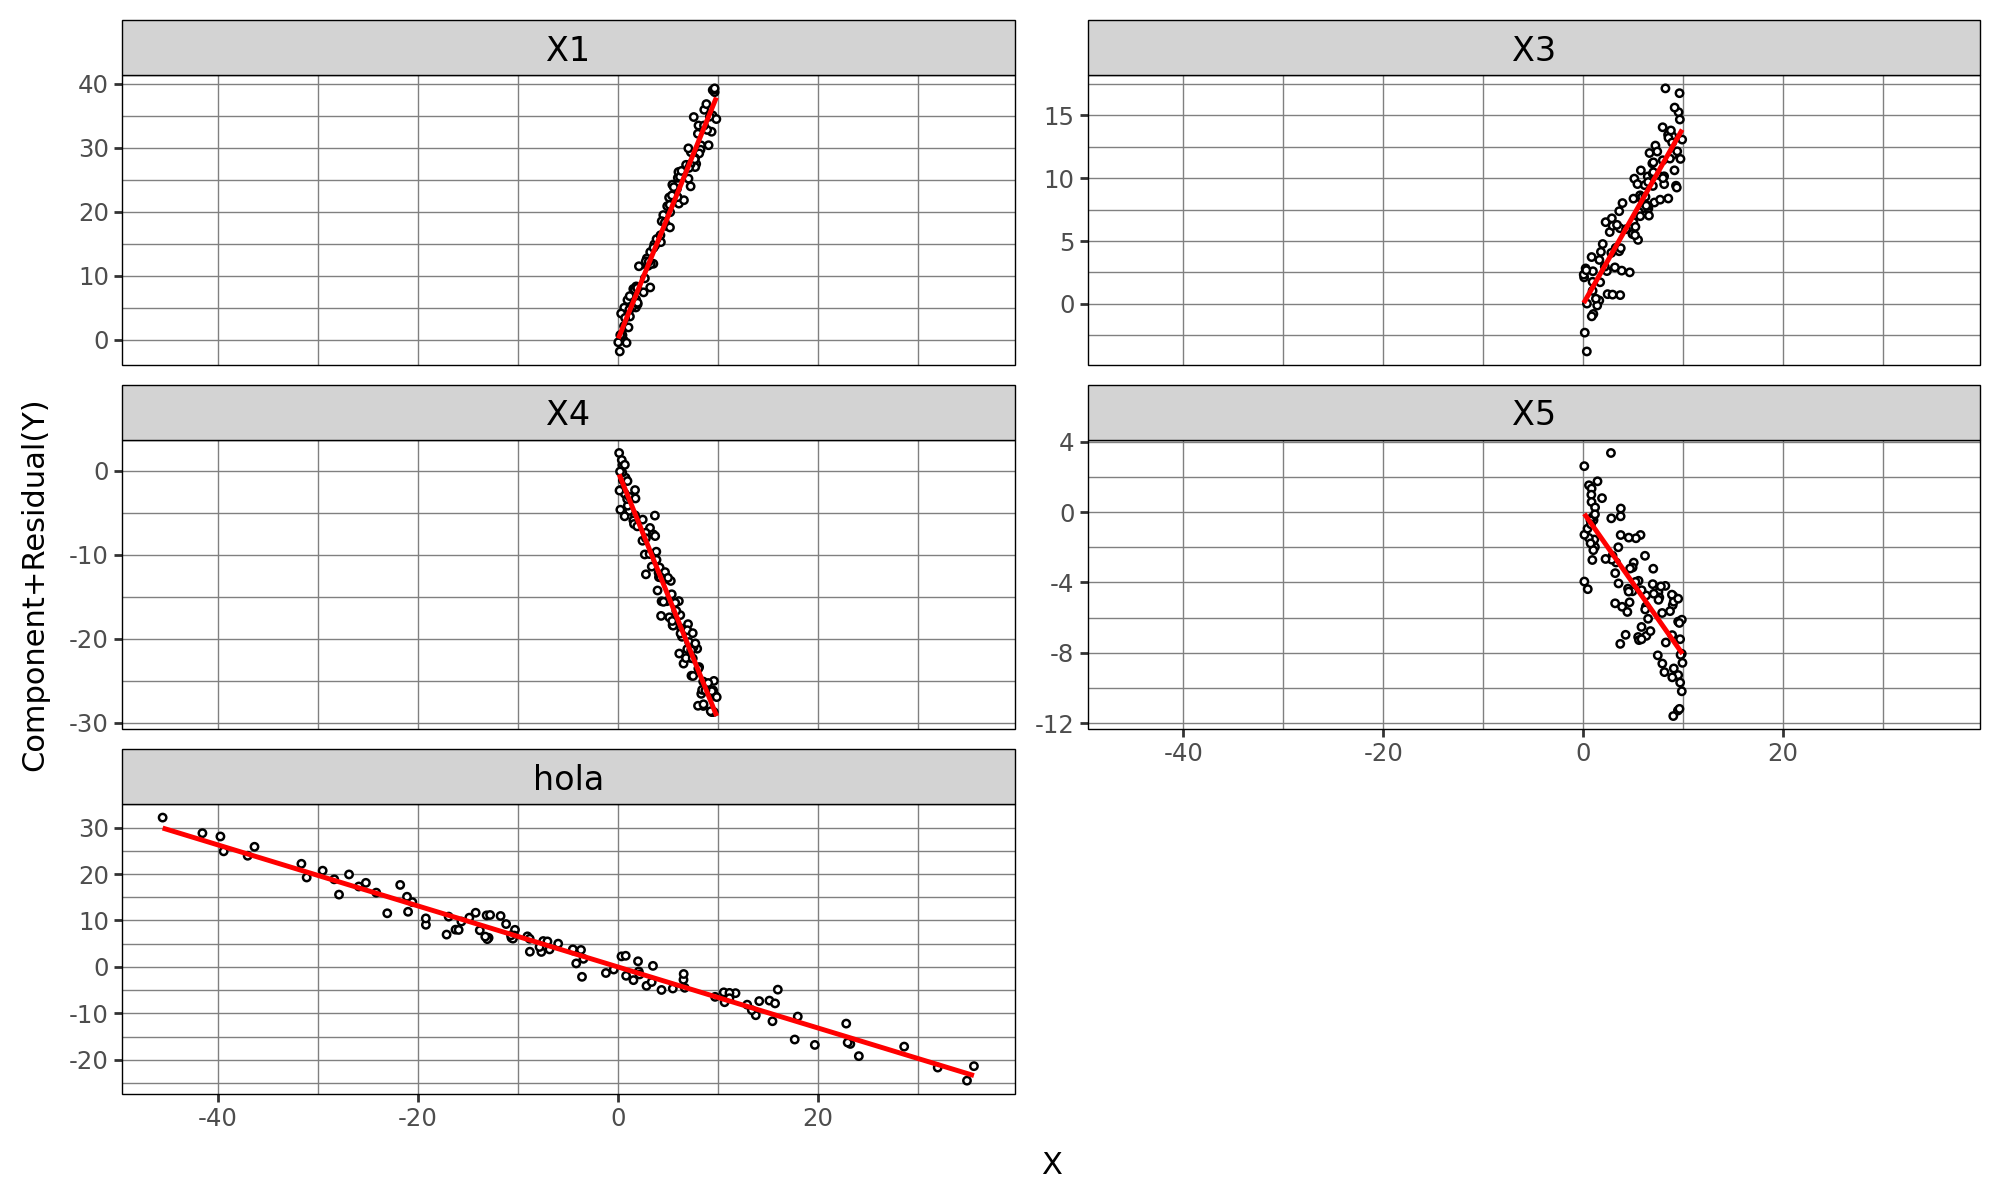

In [29]:
# Se muestran las gráficas de residuos parciales de cada una de las columnas que se utilizaron
resultado["residuos_parciales_grafica"]

<font color = 'DodgerBlue'>
<font size = 5>

---

**Paso 9. Observaciones anómalas**

<font color = 'Black'>
<font size = 3>
    
* **Leverages:** son **observaciones** con un **valor anómalo** de las variables de control. No tienen por qué afectar los **coeficientes de la regresión**.

* **Outliers de regresión:** son **observaciones** que tienen un **valor anómalo** de la variable $Y$, condicionado a los valores de sus variables independientes $X_i$. Tendrán un **residuo** muy alto pero no pueden afectar demasiado a los **coeficientes de la regresión**.

* **Observaciones influyentes:** son aquellas que tienen un **leverage alto**; son **outliers** de **regresión** y **afectan fuertemente a la regresión**.

Obtenemos los índices de las **observaciones anómalas** 
```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["indices_alto_leverage"] # puntos de apalancamiento
resultado["indices_outliers_significativos"] # puntos indices_outliers_significativos
resultado["indices_alta_influencia"] # puntos de alta influencia

################################################################
```

In [31]:
# Puntos de apalancamiento o leverages
resultado["indices_alto_leverage"] 

array([], dtype=int64)

In [32]:
# Puntos indices_outliers_significativos
resultado["indices_outliers_significativos"] 

array([43, 56, 85, 86, 92])

<font color = 'Black'>
<font size = 3>

Tenemos **Outliers** en los renglones que se muestran en el array.

Recordar que Python cuenta desde cero.

In [33]:
# Puntos de alta influencia que son peligrosos
resultado["indices_alta_influencia"] 

array([52, 56, 69, 85, 92])

<font color = 'Black'>
<font size = 3>

Tenemos **observaciones influyentes**, que son peligrosos y provocan desviaciones en la recta.

Las **observaciones influyentes**  se muestran en los renglones que se muestran en el array.

Recordar que Python cuenta desde cero.

Como tenemos **observaciones influyentes**, lo siguiente que se debería hacer es aplicar la **prueba de diagnóstico**, pero habiendo eliminado cada uno de los renglones que se indican en el array.

---

<font color = 'DodgerBlue'>
<font size = 5>

**Intervalos de confianza y significancia**

<font color = 'Black'>
<font size = 3>

Siempre es buena idea incluir los **intervalos de confianza** para los **coeficientes** $\beta_i$ y sus **significancias**.

Se puede confiar en los **intervalos de confianza**, debido a que demostramos que si hay: **Gaussianidad** en los residuos; aditividad en el modelo; linealidad en el modelo. Por lo tanto, se puede confiar en los **intervalos de confianza**.

> ⚠️ **Nota importante: si alguna de las pruebas de diagnóstico hubieran fallado, no podrías confiar en los intervalos de confianza, y no podrías presentarlos en un reporte porque no hay manera de sustentarlos.**

```python
################################################################
########################    EN PYTHON    #######################
################################################################

resultado["intervalos_de_confianza"]  # da los intervalos de confianza al 95%
resultado["modelo"].summary()  # resumen general del modelo

################################################################
```

Descripción|$p$-valor|Significado
:--|:--:|:--
¿Algún coeficiente es diferente de cero?|$<0.05$|Vale la pena hacer la regresión
¿Qué coeficientes no son cero?|$<0.05$|El coeficiente respectivo tiene efectos significativos

In [34]:
# Da los intervalos de confianza al 95%
resultado["intervalos_de_confianza"]

,0,1
const,3.529709,7.147345
X1,3.688806,3.988952
X3,1.254442,1.546247
X4,-3.232276,-2.659452
X5,-0.945776,-0.678350
hola,-0.704412,-0.609343


In [35]:
# Resumen general del modelo
resultado["modelo"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     657.4
Date:                Fri, 24 Jan 2025   Prob (F-statistic):           1.81e-71
Time:                        12:14:05   Log-Likelihood:                -211.15
No. Observations:                 100   AIC:                             434.3
Df Residuals:                      94   BIC:                             449.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3385      0.911      5.860      0.000       3.530       7.147
X1             3.8389      0.076     50.790      0.000       3.689       3.989
X3             1.4003      0.073     19.057      0.000       1.254       1.546
X4            -2.9459      0.144    -20.422      0.000      -3.232      -2.659
X5            -0.8121      0.067    -12.058      0.000      -0.946      -0.678
hola          -0.6569      0.024    -27.438      0.000      -0.704      -0.609
==============================================================================
Omnibus:                        0.796   Durbin-Watson:                   1.768
Prob(Omnibus):                  0.672   Jarque-Bera (JB):                0.851
Skew:                          -0.071   Prob(JB):                        0.654
Kurtosis:                       2.571   Cond. No.                         85.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color = 'Black'>
<font size = 3>

Como tenemos p-valores pequeños, entonces si hay **significancia** en el modelo.

> ⚠️ **Nota importante: si hubiera aparecido un p-valor grande (por ejemplo 0.5), significaría que a ese coeficiente lo puedo quitar del modelo porque no está añadiendo información.**

---

<font color = 'DodgerBlue'>
<font size = 5>

**Predicciones**

<font color = 'DodgerBlue'>
<font size = 5>

**Paso 12.**

<font color = 'Black'>
<font size = 3>

Supongamos que llegan los nuevos $j$ datos que no fueron parte de las **observaciones** de nuestra tabla original:

$X_1$|$X_2$|...|$X_k$
:--:|:--:|:--:|:--:
$x_1^{(1)}$|$x_1^{(2)}$|...|$x_1^{(k)}$
$x_2^{(1)}$|$x_2^{(2)}$|...|$x_2^{(k)}$
...|...|...|...
$x_j^{(1)}$|$x_j^{(2)}$|...|$x_j^{(k)}$

Aquí, $x_{r}^{(s)}$ representa el valor de la característica $X_s$ del nuevo individuo $r$. 

Llama ``newdata`` a la tabla anterior. Es decir, la columna 1 son los valores de la **característica** $X_1$ en los nuevos individuos; la columna 2 son los valores de la **característica** $X_2$ en los nuevos individuos; etcétera. 

**Es importante que los nombres de las columnas coincidan con los nombres de las características las características**.

```python
################################################################
########################    EN PYTHON    #######################
################################################################

new_data = # tabla de nuevos valores
new_data = new_data[resultado["predictores"]]
new_data = sm.add_constant(new_data, has_constant='add')

prediccion = resultado["modelo"].get_prediction(new_data).summary_frame(alpha=0.05)

# Mostrar resultados
print("Intervalo de confianza:")
print(prediccion[['mean', 'mean_ci_lower', 'mean_ci_upper']])

print("\nIntervalo de predicción:")
print(prediccion[['mean', 'obs_ci_lower', 'obs_ci_upper']])

################################################################
```

In [40]:
# Tabla de nuevos valores
new_data = pd.read_csv("/home/zick13/Documentos/Developer/Courses/Inferencia_Estadistica/Clases/10_Regresiones_lineales/Data/desconocidos.csv")

# Muestra la tabla
print(new_data.head())

print("------------------------------------------")

# Muestra el nombre de las columnas
print(new_data.columns)

print("------------------------------------------")

         X1        X2        X3       hola        X4        X5
0  4.937956  3.492096  5.222433 -31.123623  9.307573  3.533522
1  5.227328  7.259557  7.699936 -15.914639  8.584128  5.836561
2  4.275410  8.971103  2.158210   9.739017  4.289940  0.777346
3  0.254191  8.870864  6.228905 -10.676769  7.508711  9.743948
4  1.078914  7.798755  0.853475 -13.251963  7.545429  9.862107
------------------------------------------
Index(['X1', 'X2', 'X3', 'hola', 'X4', 'X5'], dtype='object')
------------------------------------------


In [42]:
# Nos quedamos con las columnas del modelo y con el mismo orden que tenían
new_data = new_data[resultado["predictores"]] # resultado es la respuesta del modelo, cuando le pusimos nombre a los 21 objetos que devolvía la función

# Se muestra la nueva tabla limpia y ordenada
new_data 

,X1,X3,X4,X5,hola
0,4.937956,5.222433,9.307573,3.533522,-31.123623
1,5.227328,7.699936,8.584128,5.836561,-15.914639
2,4.275410,2.158210,4.289940,0.777346,9.739017
3,0.254191,6.228905,7.508711,9.743948,-10.676769
4,1.078914,0.853475,7.545429,9.862107,-13.251963


In [44]:
# Agrega el valor constante 
new_data = sm.add_constant(new_data, has_constant='add')

In [47]:
# Construye la predicción
prediccion = resultado["modelo"].get_prediction(new_data).summary_frame(alpha=0.05)

prediccion

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,21.764075,0.443523,20.883450,22.644700,17.577161,25.950990
1,16.614814,0.473587,15.674496,17.555131,12.414939,20.814689
2,5.107368,0.476353,4.161558,6.053177,0.906260,9.308475
3,-7.982060,0.598329,-9.170057,-6.794063,-12.244230,-3.719891
4,-10.856032,0.586553,-12.020646,-9.691418,-15.111744,-6.600321


In [48]:
# Mostrar resultados
print("Intervalo de confianza:")
print(prediccion[['mean', 'mean_ci_lower', 'mean_ci_upper']])

Intervalo de confianza:
        mean  mean_ci_lower  mean_ci_upper
0  21.764075      20.883450      22.644700
1  16.614814      15.674496      17.555131
2   5.107368       4.161558       6.053177
3  -7.982060      -9.170057      -6.794063
4 -10.856032     -12.020646      -9.691418


<font color = 'Black'>
<font size = 3>

Lo que nos dicen los resultados es:

- el índice que se muestra al inicio de la tabla corresponde al renglón.
- **mean** es el valor de la $Y$ que buscamos predecir.
- así te sigues con cada uno de los resultados.

Con esto ya puedes predecir los valores cuando te llegue una tabla nueva.

---

<font color = 'lightseagreen'>
<font size = 5>

**Reflexión final**

<font color = 'midnightblue'>
<font size = 3>

Antes de atacar un problema, mire la pregunta que usted quiere contestar y los datos de que dispone. Es muy factible que, luego de un análisis razonable, usted, que ha ido a las bases, note que lo que hace falta se reduce a un cálculo de probabilidades condicionales en el que muy seguramente es complicado establecer la independencia estadística de algunas de las variables. En ese caso, use un algoritmo naive Bayes y entregue los resultados a la gerencia; estoy seguro de que se lo agradeceran.

<font color = 'Brown'>
<font size = 4>
    
**Notas**

<font color = 'DarkRed'>
<font size = 3>

- El $R^{2}$ es una medida de la **variabilidad** de los **datos**. Es decir, qué tanto explica la **regresión** a la variabilidad total. Entre más próximo a 1 fuera es porque es mejor la explicación, entonces el modelo es más exacto.
- Cuando aumentas columnas sin querer estás cambiando de manera artifical cambias al $R^{2}$.
- El **$R^{2}$ ajustado** penaliza en número de columnas explicativas que tienes. Es decir, que de alguna manera controla que, aunque aumentes el número de columnas al modelo, tu $R^{2}$ no se vaya a disparar de manera artificial.
- En la **regresión lineal simple** el importante es el $R^{2}$.
- En la **regresión lineal múltiple** es el **$R^{2}$ ajustado**.
- El **$R^{2}$ ajustado** siempre es más pequeño que el $R^{2}$. Como es más difícil que llegue a 1, por eso te da una mejor medida.
> ⚠️ **Nota importante: No siempre que tengas muchas columnas significa que tienes mejor información.**
- El **índice de akaike** mide la información y por eso te quita la información redundante.